# 01. Exploración inicial

Carga rápida de la geometría de barrios y los puntos de recarga existentes para verificar la integridad de los datos y obtener una primera vista del territorio de análisis.

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8')

In [2]:
gdf_barrios = gpd.read_file('../data/raw/neighbourhoods.geojson')
print(f"Cargados {len(gdf_barrios)} barrios.")
print(gdf_barrios.head(3))

df_cargadores = pd.read_csv('../data/raw/puntos_recarga_barcelona.csv')
gdf_cargadores = gpd.GeoDataFrame(
    df_cargadores,
    geometry=gpd.points_from_xy(df_cargadores['Station_lng'], df_cargadores['Station_lat']),
    crs="EPSG:4326"
)
print(f"Cargados {len(gdf_cargadores)} puntos de recarga.")

Cargados 75 barrios.
            neighbourhood neighbourhood_group  \
0                el Raval        Ciutat Vella   
1          el Barri Gòtic        Ciutat Vella   
2  la Dreta de l'Eixample            Eixample   

                                            geometry  
0  MULTIPOLYGON (((2.17737 41.37532, 2.17852 41.3...  
1  MULTIPOLYGON (((2.18287 41.38074, 2.18289 41.3...  
2  MULTIPOLYGON (((2.17091 41.40182, 2.17332 41.3...  
Cargados 393 puntos de recarga.


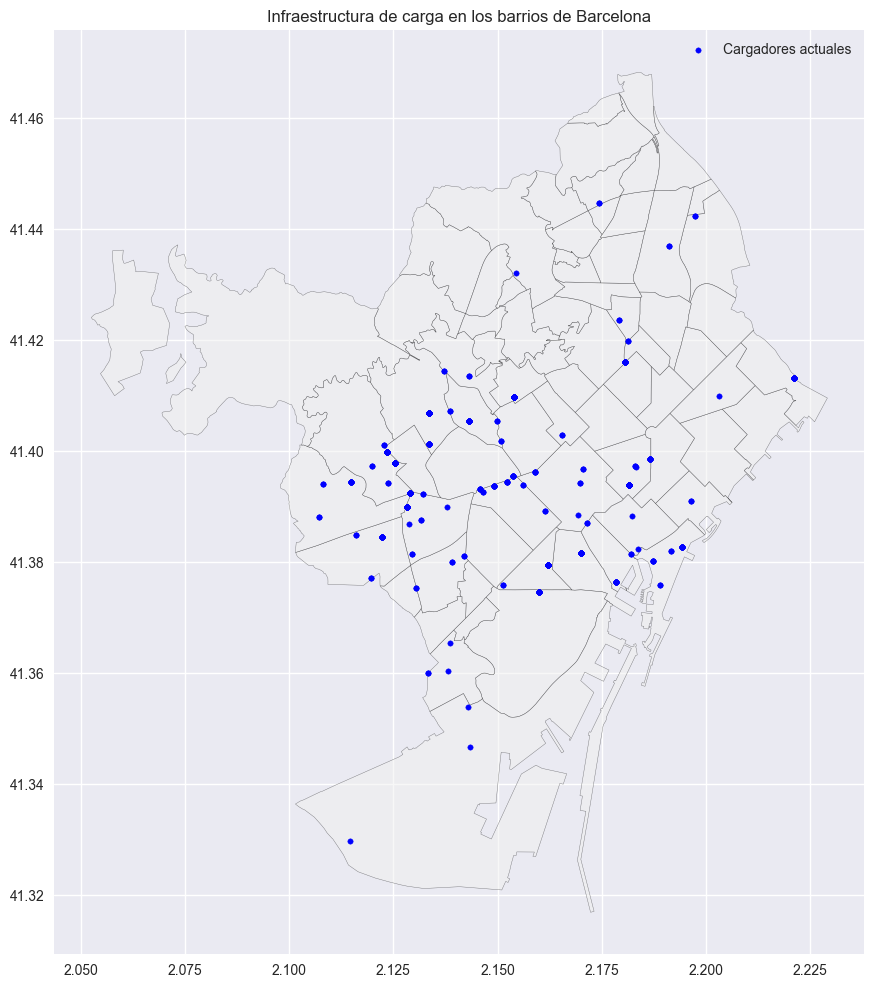

In [3]:
fig, ax = plt.subplots(figsize=(12, 12))
gdf_barrios.plot(ax=ax, color='#f0f0f0', edgecolor='black', alpha=0.5)
gdf_cargadores.plot(ax=ax, color='blue', markersize=15, label='Cargadores actuales')
ax.set_title('Infraestructura de carga en los barrios de Barcelona')
plt.legend()
plt.show()